# Speed-up Analysis 
We try different combination of number of executors and memory per executor to perform speed-up analysis. The model is XGBoost with PCA.

In [12]:
import time

from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    HashingTF,
    StringIndexer,
    PCA
)

from xgboost.spark import SparkXGBClassifier


NUM_EXECUTORS = 1     
CORES_PER_EXECUTOR = 4
MEMORY_PER_EXECUTOR = 16
DRIVER_MEMORY = 8


try:
    spark.stop()
except:
    pass


spark = SparkSession.builder \
    .appName(f"PCA-XGBoost-Speedup-{NUM_EXECUTORS}-Executors") \
    .config("spark.executor.instances", str(NUM_EXECUTORS)) \
    .config("spark.executor.cores", str(CORES_PER_EXECUTOR)) \
    .config("spark.executor.memory", f"{MEMORY_PER_EXECUTOR}g") \
    .config("spark.driver.memory", f"{DRIVER_MEMORY}g") \
    .config("spark.executor.memoryOverhead", "4g") \
    .config("spark.sql.shuffle.partitions", "256") \
    .config("spark.default.parallelism", "256") \
    .config("spark.sql.files.ignoreCorruptFiles", "true") \
    .getOrCreate()


print("Loading modeling dataset...")

df = spark.read.parquet("data/final_top100_full")

train_data, test_data = df.randomSplit(
    [0.8, 0.2],
    seed=42
)


tokenizer = RegexTokenizer(
    inputCol="self_text",
    outputCol="words",
    pattern="\\W+"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="features",
    numFeatures=2000
)

label_indexer = StringIndexer(
    inputCol="subreddit",
    outputCol="label",
    handleInvalid="skip"
)

pca = PCA(
    k=50,
    inputCol="features",
    outputCol="pca_features"
)

xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    raw_prediction_col="rawPrediction",
    num_class=100,
    num_workers=NUM_EXECUTORS,
    max_depth=3,
    n_estimators=20,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    seed=42
)

pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    pca,
    xgb
])


print(f"\nStarting {NUM_EXECUTORS} executor run...")

start = time.time()

model = pipeline.fit(train_data)

preds = model.transform(test_data)

rows = preds.select("prediction").count()

elapsed = time.time() - start


print("\nRUN COMPLETE")
print("Executors:", NUM_EXECUTORS)
print("Rows predicted:", rows)
print(f"Measured time: {elapsed:.2f} sec")

print("\nSAVE THIS TIME:")
print(elapsed)

Loading modeling dataset...

Starting 1 executor run...


INFO:XGBoost-PySpark:Running xgboost-2.0.3 on 1 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'num_class': 100, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 20}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!



RUN COMPLETE
Executors: 1
Rows predicted: 2824464
Measured time: 8494.26 sec

SAVE THIS TIME:
8494.263770103455


In [13]:
NUM_EXECUTORS = 7    
CORES_PER_EXECUTOR = 4
MEMORY_PER_EXECUTOR = 16
DRIVER_MEMORY = 8


try:
    spark.stop()
except:
    pass


spark = SparkSession.builder \
    .appName(f"PCA-XGBoost-Speedup-{NUM_EXECUTORS}-Executors") \
    .config("spark.executor.instances", str(NUM_EXECUTORS)) \
    .config("spark.executor.cores", str(CORES_PER_EXECUTOR)) \
    .config("spark.executor.memory", f"{MEMORY_PER_EXECUTOR}g") \
    .config("spark.driver.memory", f"{DRIVER_MEMORY}g") \
    .config("spark.executor.memoryOverhead", "4g") \
    .config("spark.sql.shuffle.partitions", "256") \
    .config("spark.default.parallelism", "256") \
    .config("spark.sql.files.ignoreCorruptFiles", "true") \
    .getOrCreate()


print("Loading modeling dataset...")

df = spark.read.parquet("data/final_top100_full")

train_data, test_data = df.randomSplit(
    [0.8, 0.2],
    seed=42
)


tokenizer = RegexTokenizer(
    inputCol="self_text",
    outputCol="words",
    pattern="\\W+"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="features",
    numFeatures=2000
)

label_indexer = StringIndexer(
    inputCol="subreddit",
    outputCol="label",
    handleInvalid="skip"
)

pca = PCA(
    k=50,
    inputCol="features",
    outputCol="pca_features"
)

xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    raw_prediction_col="rawPrediction",
    num_class=100,
    num_workers=NUM_EXECUTORS,
    max_depth=3,
    n_estimators=20,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    seed=42
)

pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    pca,
    xgb
])


print(f"\nStarting {NUM_EXECUTORS} executor run...")

start = time.time()

model = pipeline.fit(train_data)

preds = model.transform(test_data)

rows = preds.select("prediction").count()

elapsed = time.time() - start


print("\nRUN COMPLETE")
print("Executors:", NUM_EXECUTORS)
print("Rows predicted:", rows)
print(f"Measured time: {elapsed:.2f} sec")

print("\nSAVE THIS TIME:")
print(elapsed)

Loading modeling dataset...

Starting 7 executor run...


INFO:XGBoost-PySpark:Running xgboost-2.0.3 on 7 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'num_class': 100, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 20}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!



RUN COMPLETE
Executors: 7
Rows predicted: 2824464
Measured time: 6060.01 sec

SAVE THIS TIME:
6060.014940977097


In [2]:
import time

from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    HashingTF,
    StringIndexer,
    PCA
)

from xgboost.spark import SparkXGBClassifier

NUM_EXECUTORS = 4    
CORES_PER_EXECUTOR = 4
MEMORY_PER_EXECUTOR = 24
DRIVER_MEMORY = 8


try:
    spark.stop()
except:
    pass


spark = SparkSession.builder \
    .appName(f"PCA-XGBoost-Speedup-{NUM_EXECUTORS}-Executors") \
    .config("spark.executor.instances", str(NUM_EXECUTORS)) \
    .config("spark.executor.cores", str(CORES_PER_EXECUTOR)) \
    .config("spark.executor.memory", f"{MEMORY_PER_EXECUTOR}g") \
    .config("spark.driver.memory", f"{DRIVER_MEMORY}g") \
    .config("spark.executor.memoryOverhead", "4g") \
    .config("spark.sql.shuffle.partitions", "256") \
    .config("spark.default.parallelism", "256") \
    .config("spark.sql.files.ignoreCorruptFiles", "true") \
    .getOrCreate()


print("Loading modeling dataset...")

df = spark.read.parquet("data/final_top100_full")

train_data, test_data = df.randomSplit(
    [0.8, 0.2],
    seed=42
)


tokenizer = RegexTokenizer(
    inputCol="self_text",
    outputCol="words",
    pattern="\\W+"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="features",
    numFeatures=2000
)

label_indexer = StringIndexer(
    inputCol="subreddit",
    outputCol="label",
    handleInvalid="skip"
)

pca = PCA(
    k=50,
    inputCol="features",
    outputCol="pca_features"
)

xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    raw_prediction_col="rawPrediction",
    num_class=100,
    num_workers=NUM_EXECUTORS,
    max_depth=3,
    n_estimators=20,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    seed=42
)

pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    pca,
    xgb
])


print(f"\nStarting {NUM_EXECUTORS} executor run...")

start = time.time()

model = pipeline.fit(train_data)

preds = model.transform(test_data)

rows = preds.select("prediction").count()

elapsed = time.time() - start


print("\nRUN COMPLETE")
print("Executors:", NUM_EXECUTORS)
print("Rows predicted:", rows)
print(f"Measured time: {elapsed:.2f} sec")

print("\nSAVE THIS TIME:")
print(elapsed)

Loading modeling dataset...

Starting 4 executor run...


2026-05-27 19:29:47,748 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 4 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'num_class': 100, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 20}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-27 19:46:32,853 INFO XGBoost-PySpark: _fit Finished xgboost training!



RUN COMPLETE
Executors: 4
Rows predicted: 2824464
Measured time: 6422.91 sec

SAVE THIS TIME:
6422.906773805618


In [3]:
NUM_EXECUTORS = 1    
CORES_PER_EXECUTOR = 4
MEMORY_PER_EXECUTOR = 64
DRIVER_MEMORY = 8


try:
    spark.stop()
except:
    pass


spark = SparkSession.builder \
    .appName(f"PCA-XGBoost-Speedup-{NUM_EXECUTORS}-Executors") \
    .config("spark.executor.instances", str(NUM_EXECUTORS)) \
    .config("spark.executor.cores", str(CORES_PER_EXECUTOR)) \
    .config("spark.executor.memory", f"{MEMORY_PER_EXECUTOR}g") \
    .config("spark.driver.memory", f"{DRIVER_MEMORY}g") \
    .config("spark.executor.memoryOverhead", "4g") \
    .config("spark.sql.shuffle.partitions", "256") \
    .config("spark.default.parallelism", "256") \
    .config("spark.sql.files.ignoreCorruptFiles", "true") \
    .getOrCreate()


print("Loading modeling dataset...")

df = spark.read.parquet("data/final_top100_full")

train_data, test_data = df.randomSplit(
    [0.8, 0.2],
    seed=42
)


tokenizer = RegexTokenizer(
    inputCol="self_text",
    outputCol="words",
    pattern="\\W+"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="features",
    numFeatures=2000
)

label_indexer = StringIndexer(
    inputCol="subreddit",
    outputCol="label",
    handleInvalid="skip"
)

pca = PCA(
    k=50,
    inputCol="features",
    outputCol="pca_features"
)

xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    raw_prediction_col="rawPrediction",
    num_class=100,
    num_workers=NUM_EXECUTORS,
    max_depth=3,
    n_estimators=20,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    seed=42
)

pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    pca,
    xgb
])


print(f"\nStarting {NUM_EXECUTORS} executor run...")

start = time.time()

model = pipeline.fit(train_data)

preds = model.transform(test_data)

rows = preds.select("prediction").count()

elapsed = time.time() - start


print("\nRUN COMPLETE")
print("Executors:", NUM_EXECUTORS)
print("Rows predicted:", rows)
print(f"Measured time: {elapsed:.2f} sec")

print("\nSAVE THIS TIME:")
print(elapsed)

Loading modeling dataset...

Starting 1 executor run...


2026-05-27 21:16:10,009 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 1 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'num_class': 100, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 20}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-27 22:07:55,716 INFO XGBoost-PySpark: _fit Finished xgboost training!



RUN COMPLETE
Executors: 1
Rows predicted: 2824464
Measured time: 8481.92 sec

SAVE THIS TIME:
8481.924111366272


In [4]:
NUM_EXECUTORS = 15     
CORES_PER_EXECUTOR = 2
MEMORY_PER_EXECUTOR = 6
DRIVER_MEMORY = 8


try:
    spark.stop()
except:
    pass


spark = SparkSession.builder \
    .appName(f"PCA-XGBoost-Speedup-{NUM_EXECUTORS}-Executors") \
    .config("spark.executor.instances", str(NUM_EXECUTORS)) \
    .config("spark.executor.cores", str(CORES_PER_EXECUTOR)) \
    .config("spark.executor.memory", f"{MEMORY_PER_EXECUTOR}g") \
    .config("spark.driver.memory", f"{DRIVER_MEMORY}g") \
    .config("spark.executor.memoryOverhead", "4g") \
    .config("spark.sql.shuffle.partitions", "256") \
    .config("spark.default.parallelism", "256") \
    .config("spark.sql.files.ignoreCorruptFiles", "true") \
    .getOrCreate()


print("Loading modeling dataset...")

df = spark.read.parquet("data/final_top100_full")

train_data, test_data = df.randomSplit(
    [0.8, 0.2],
    seed=42
)


tokenizer = RegexTokenizer(
    inputCol="self_text",
    outputCol="words",
    pattern="\\W+"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="features",
    numFeatures=2000
)

label_indexer = StringIndexer(
    inputCol="subreddit",
    outputCol="label",
    handleInvalid="skip"
)

pca = PCA(
    k=50,
    inputCol="features",
    outputCol="pca_features"
)

xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    raw_prediction_col="rawPrediction",
    num_class=100,
    num_workers=NUM_EXECUTORS,
    max_depth=3,
    n_estimators=20,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    seed=42
)

pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    pca,
    xgb
])


print(f"\nStarting {NUM_EXECUTORS} executor run...")

start = time.time()

model = pipeline.fit(train_data)

preds = model.transform(test_data)

rows = preds.select("prediction").count()

elapsed = time.time() - start


print("\nRUN COMPLETE")
print("Executors:", NUM_EXECUTORS)
print("Rows predicted:", rows)
print(f"Measured time: {elapsed:.2f} sec")

print("\nSAVE THIS TIME:")
print(elapsed)

Loading modeling dataset...

Starting 15 executor run...


2026-05-27 23:37:30,420 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 15 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'num_class': 100, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 20}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-27 23:47:21,640 INFO XGBoost-PySpark: _fit Finished xgboost training!



RUN COMPLETE
Executors: 15
Rows predicted: 2824464
Measured time: 5964.49 sec

SAVE THIS TIME:
5964.490496397018


## Results

In [2]:
T1 = 8481.924111366272    # 1 executor 
T4 = 6422.906773805618    # 4 executor

speedup = T1 / T4
efficiency = speedup / 4

p = (
    4 * (speedup - 1)
) / (
    speedup * (4 - 1)
)

print(f"Speedup: {speedup:.2f}x")
print(f"Efficiency: {efficiency:.2%}")
print(f"Parallelizable fraction: {p:.2%}")

Speedup: 1.32x
Efficiency: 33.01%
Parallelizable fraction: 32.37%


In [3]:
T1 = 8481.924111366272    # 1 executor 
T7 = 6060.014940977097    # 7 executor

speedup = T1 / T7
efficiency = speedup / 7

p = (
    7 * (speedup - 1)
) / (
    speedup * (7 - 1)
)

print(f"Speedup: {speedup:.2f}x")
print(f"Efficiency: {efficiency:.2%}")
print(f"Parallelizable fraction: {p:.2%}")

Speedup: 1.40x
Efficiency: 20.00%
Parallelizable fraction: 33.31%


In [4]:
T1 = 8481.924111366272    # 1 executor 
T15 = 5964.490496397018   # 15 executor

speedup = T1 / T15
efficiency = speedup / 15

p = (
    15 * (speedup - 1)
) / (
    speedup * (15 - 1)
)

print(f"Speedup: {speedup:.2f}x")
print(f"Efficiency: {efficiency:.2%}")
print(f"Parallelizable fraction: {p:.2%}")

Speedup: 1.42x
Efficiency: 9.48%
Parallelizable fraction: 31.80%


In [6]:
import pandas as pd

# put your measured times here
T1 = 8481.924111366272
T4 = 6422.906773805618
T7 = 6060.014940977097
T15 = 5964.490496397018


results = [
    [1, 64, T1],
    [4, 24, T4],
    [7, 16, T7],
    [15, 6, T15]
]


table = []

for executors, memory, time_sec in results:

    if time_sec == 0:
        speedup = None
        efficiency = None
    else:
        speedup = T1 / time_sec
        efficiency = speedup / executors

    table.append([
        executors,
        f"{memory}GB",
        round(time_sec, 2) if time_sec != 0 else "Pending",
        f"{speedup:.2f}x" if speedup else "Pending",
        f"{efficiency:.1%}" if efficiency else "Pending"
    ])


df_table = pd.DataFrame(
    table,
    columns=[
        "Executors",
        "Memory/Exec",
        "Time (sec)",
        "Speedup",
        "Efficiency"
    ]
)

print(df_table)


print("\nREADME Table:\n")

print("| Executors | Memory/Exec | Time (sec) | Speedup | Efficiency |")
print("|-----------|--------------|-------------|----------|-------------|")

for row in table:
    print(
        f"| {row[0]} | {row[1]} | "
        f"{row[2]} | {row[3]} | {row[4]} |"
    )

   Executors Memory/Exec  Time (sec) Speedup Efficiency
0          1        64GB     8481.92   1.00x     100.0%
1          4        24GB     6422.91   1.32x      33.0%
2          7        16GB     6060.01   1.40x      20.0%
3         15         6GB     5964.49   1.42x       9.5%

README Table:

| Executors | Memory/Exec | Time (sec) | Speedup | Efficiency |
|-----------|--------------|-------------|----------|-------------|
| 1 | 64GB | 8481.92 | 1.00x | 100.0% |
| 4 | 24GB | 6422.91 | 1.32x | 33.0% |
| 7 | 16GB | 6060.01 | 1.40x | 20.0% |
| 15 | 6GB | 5964.49 | 1.42x | 9.5% |


# Model Comparison
Comparing our baseline Naive Bayes' model with PCA + XGBoost model.

Training dataset includes a combined text feature of "title" and "self_text". To lessen the issue of imbalanced data, we use only the top 100 subreddit labels.

## 16 workers
Results printed at bottom of subsection.

Finding top 100 subreddits...
Rows used: 14112094
Train rows: 11287630
Test rows: 2824464
Training baseline Naive Bayes model...
Training PCA + XGBoost model...


INFO:XGBoost-PySpark:Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'num_class': 100, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 20}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!



Results
Baseline Train Accuracy: 0.5724
Baseline Test Accuracy:  0.5715
Baseline Test F1:        0.5564

PCA XGBoost Train Accuracy: 0.3162
PCA XGBoost Test Accuracy:  0.3159
PCA XGBoost Test F1:        0.2630

PCA Explained Variance
Total explained variance: 0.6248
First 10 components:
PC1: 0.236053
PC2: 0.041906
PC3: 0.031039
PC4: 0.027319
PC5: 0.022965
PC6: 0.021760
PC7: 0.019578
PC8: 0.014357
PC9: 0.013182
PC10: 0.012080


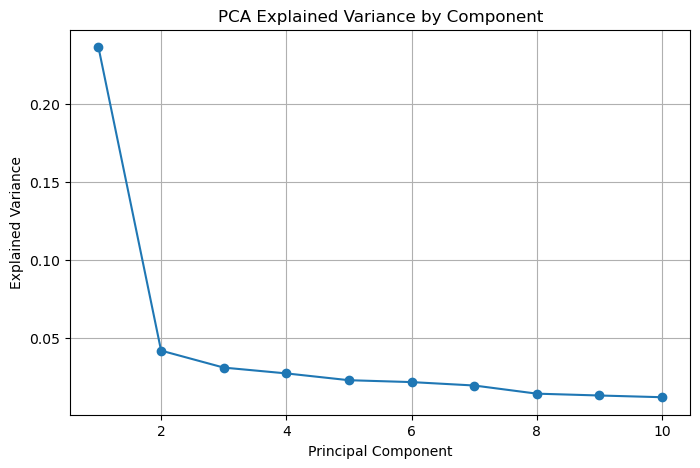


Correct predictions with subreddit names
+----------------+-------------------+------------------------------------------------------------------------------------------------------------------------+
|actual_subreddit|predicted_subreddit|                                                                                                               self_text|
+----------------+-------------------+------------------------------------------------------------------------------------------------------------------------+
|            ADHD|               ADHD|I'm currently a sophomore in a four-year college, but I've been struggling in Calc 2 (Integral Calculus) which is a g...|
|            ADHD|               ADHD|I've got a bad head cold and sore throat (Corona rapid test negative).  I'd like to take a half dose of Nyquil (one g...|
|            ADHD|               ADHD|Some background to why I'm asking this question. I'm currently studying at a university majoring in education. As mor...

In [14]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    HashingTF,
    StringIndexer,
    PCA,
    IndexToString
)
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from xgboost.spark import SparkXGBClassifier

import matplotlib.pyplot as plt


# spark setup
spark = SparkSession.builder \
    .appName("Final-Subreddit-PCA-XGBoost") \
    .config("spark.driver.memory", "24g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.driver.memoryOverhead", "6g") \
    .config("spark.executor.memoryOverhead", "6g") \
    .config("spark.sql.shuffle.partitions", "256") \
    .config("spark.default.parallelism", "256") \
    .config("spark.sql.files.ignoreCorruptFiles", "true") \
    .getOrCreate()


# load data
df = spark.read.parquet("../gkao/shared_notebook/data/filtered2")

TARGET_COL = "subreddit"

# drop columns we are not using
drop_cols = ["over_18", "post_id", "link_flair_text", "title"]

for c in drop_cols:
    if c in df.columns:
        df = df.drop(c)


# clean text
df_clean = (
    df.dropna(subset=["self_text", TARGET_COL])
      .filter(F.col("self_text") != "")
      .filter(F.length(F.col("self_text")) < 50000)
)


print("Finding top 100 subreddits...")

top_100_df = (
    df_clean.groupBy(TARGET_COL)
    .count()
    .orderBy(F.desc("count"))
    .limit(100)
    .select(TARGET_COL)
)

df_top_100 = df_clean.join(
    top_100_df,
    on=TARGET_COL,
    how="inner"
)


# use full top 100 dataset
df_model = df_top_100


# save and reload so Spark has a simpler job
temp_path = "data/final_top100_full"

df_model.write.mode("overwrite").parquet(temp_path)
df_model = spark.read.parquet(temp_path)

print("Rows used:", df_model.count())


# split data
train_data, test_data = df_model.randomSplit(
    [0.8, 0.2],
    seed=42
)

train_data = train_data.cache()
test_data = test_data.cache()

print("Train rows:", train_data.count())
print("Test rows:", test_data.count())


# text steps
tokenizer = RegexTokenizer(
    inputCol="self_text",
    outputCol="words",
    pattern="\\W+"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="features",
    numFeatures=2000
)

label_indexer = StringIndexer(
    inputCol=TARGET_COL,
    outputCol="label",
    handleInvalid="skip"
)


# baseline model
nb_full = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    smoothing=0.1,
    modelType="multinomial"
)

baseline_pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    nb_full
])

print("Training baseline Naive Bayes model...")

baseline_model = baseline_pipeline.fit(train_data)

baseline_train_preds = baseline_model.transform(train_data)
baseline_test_preds = baseline_model.transform(test_data)


# PCA for second model
pca = PCA(
    k=50,
    inputCol="features",
    outputCol="pca_features"
)


# XGBoost after PCA
xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    raw_prediction_col="rawPrediction",
    num_class=100,
    num_workers=16,
    max_depth=3,
    n_estimators=20,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    seed=42
)

pca_xgb_pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    pca,
    xgb
])

print("Training PCA + XGBoost model...")

pca_xgb_model = pca_xgb_pipeline.fit(train_data)

pca_xgb_train_preds = pca_xgb_model.transform(train_data)
pca_xgb_test_preds = pca_xgb_model.transform(test_data)


# evaluators
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)


# baseline scores
baseline_train_acc = accuracy_eval.evaluate(baseline_train_preds)
baseline_test_acc = accuracy_eval.evaluate(baseline_test_preds)
baseline_test_f1 = f1_eval.evaluate(baseline_test_preds)


# PCA XGBoost scores
pca_xgb_train_acc = accuracy_eval.evaluate(pca_xgb_train_preds)
pca_xgb_test_acc = accuracy_eval.evaluate(pca_xgb_test_preds)
pca_xgb_test_f1 = f1_eval.evaluate(pca_xgb_test_preds)


print("\nResults")
print(f"Baseline Train Accuracy: {baseline_train_acc:.4f}")
print(f"Baseline Test Accuracy:  {baseline_test_acc:.4f}")
print(f"Baseline Test F1:        {baseline_test_f1:.4f}")

print(f"\nPCA XGBoost Train Accuracy: {pca_xgb_train_acc:.4f}")
print(f"PCA XGBoost Test Accuracy:  {pca_xgb_test_acc:.4f}")
print(f"PCA XGBoost Test F1:        {pca_xgb_test_f1:.4f}")


# explained variance
pca_stage = pca_xgb_model.stages[-2]

explained_variance = pca_stage.explainedVariance.toArray()
total_explained = float(explained_variance.sum())

print("\nPCA Explained Variance")
print(f"Total explained variance: {total_explained:.4f}")

print("First 10 components:")

for i, val in enumerate(explained_variance[:10]):
    print(f"PC{i+1}: {val:.6f}")


# explained variance graph
pc_nums = list(range(1, 11))
pc_vals = explained_variance[:10]

plt.figure(figsize=(8, 5))
plt.plot(pc_nums, pc_vals, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("PCA Explained Variance by Component")
plt.grid(True)
plt.show()


# decode label numbers back to subreddit names
label_model = pca_xgb_model.stages[3]

label_converter = IndexToString(
    inputCol="label",
    outputCol="actual_subreddit",
    labels=label_model.labels
)

prediction_converter = IndexToString(
    inputCol="prediction",
    outputCol="predicted_subreddit",
    labels=label_model.labels
)

decoded_preds = label_converter.transform(pca_xgb_test_preds)
decoded_preds = prediction_converter.transform(decoded_preds)


# correct predictions with subreddit names
correct_named = (
    decoded_preds
    .filter(F.col("actual_subreddit") == F.col("predicted_subreddit"))
    .select(
        "actual_subreddit",
        "predicted_subreddit",
        "self_text"
    )
    .limit(5)
)

print("\nCorrect predictions with subreddit names")
correct_named.show(5, truncate=120)


# wrong predictions with subreddit names
wrong_named = (
    decoded_preds
    .filter(F.col("actual_subreddit") != F.col("predicted_subreddit"))
    .select(
        "actual_subreddit",
        "predicted_subreddit",
        "self_text"
    )
    .limit(10)
)

print("\nFalse positive / false negative examples with subreddit names")
wrong_named.show(10, truncate=120)


# save model results
results = spark.createDataFrame([
    (
        "Baseline Naive Bayes Full Features",
        float(baseline_train_acc),
        float(baseline_test_acc),
        float(baseline_test_f1),
        None
    ),
    (
        "PCA + XGBoost Reduced Features",
        float(pca_xgb_train_acc),
        float(pca_xgb_test_acc),
        float(pca_xgb_test_f1),
        total_explained
    )
], [
    "model",
    "train_accuracy",
    "test_accuracy",
    "test_f1",
    "explained_variance"
])

results.show(truncate=False)

results.write.mode("overwrite").csv(
    "data/final_model_results_xgboost",
    header=True
)

## 8 workers
Results printed at bottom of subsection. Similar pipeline and model but with different hyperparameters - the number of features for hashing increased from 2000 to 3000, and the XGBoost model number of estimators increased from 20 to 50. This allows more intricacies during the training process and thus yields better accuracy.

Matplotlib created a temporary cache directory at /scratch/akarim1/job_49849888/matplotlib-4w5r876s because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Finding top 100 subreddits...
Rows used: 14112094
Train rows: 11288808
Test rows: 2823286
Training baseline Naive Bayes model...
Training PCA + XGBoost model...


2026-05-28 23:08:21,311 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 8 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.9, 'device': 'cpu', 'learning_rate': 0.08, 'max_depth': 4, 'subsample': 0.9, 'num_class': 100, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-28 23:52:38,017 INFO XGBoost-PySpark: _fit Finished xgboost training!



Results
Baseline Train Accuracy: 0.6557
Baseline Test Accuracy:  0.6550
Baseline Test F1:        0.6442

PCA XGBoost Train Accuracy: 0.4088
PCA XGBoost Test Accuracy:  0.4075
PCA XGBoost Test F1:        0.3659

PCA Explained Variance
Total explained variance: 0.6220
First 10 components:
PC1: 0.225011
PC2: 0.035798
PC3: 0.029808
PC4: 0.025835
PC5: 0.020691
PC6: 0.019538
PC7: 0.017141
PC8: 0.015849
PC9: 0.014299
PC10: 0.013341


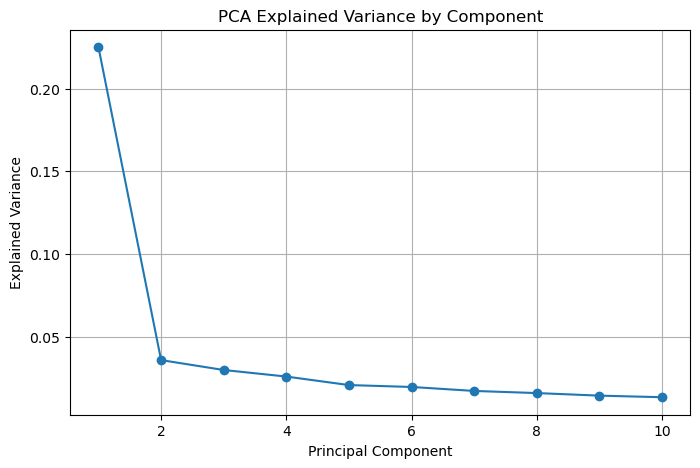


Correct predictions with subreddit names
+----------------+-------------------+------------------------------------------------------------------------------------------------------------------------+
|actual_subreddit|predicted_subreddit|                                                                                                           combined_text|
+----------------+-------------------+------------------------------------------------------------------------------------------------------------------------+
|            ADHD|               ADHD|ADHD Testers booked up for months I am an adult who has been informed it's very likely I have ADHD and it was somehow...|
|            ADHD|               ADHD|ADHD evaluations and HIPAA "TL;DR- Isn't involving a third party for an ADHD diagnosis a privacy violation?  Okay, so...|
|            ADHD|               ADHD|Adderall side effects Since July I’ve been through trying Concerta, Ritalin, Vyvanse, now finally Adderall IR and I f...

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    HashingTF,
    StringIndexer,
    PCA,
    IndexToString
)
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from xgboost.spark import SparkXGBClassifier

import matplotlib.pyplot as plt


spark = SparkSession.builder \
    .appName("Final-Subreddit-PCA-XGBoost") \
    .config("spark.driver.memory", "24g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.driver.memoryOverhead", "6g") \
    .config("spark.executor.memoryOverhead", "6g") \
    .config("spark.sql.shuffle.partitions", "256") \
    .config("spark.default.parallelism", "256") \
    .config("spark.sql.files.ignoreCorruptFiles", "true") \
    .getOrCreate()


df = spark.read.parquet("../gkao/shared_notebook/data/filtered2")

TARGET_COL = "subreddit"


# combine title and body text
df = df.withColumn(
    "combined_text",
    F.concat_ws(" ", F.col("title"), F.col("self_text"))
)


# drop stuff we are not using
drop_cols = ["over_18", "post_id", "link_flair_text", "title", "self_text"]

for c in drop_cols:
    if c in df.columns:
        df = df.drop(c)


# clean text
df_clean = (
    df.dropna(subset=["combined_text", TARGET_COL])
      .filter(F.col("combined_text") != "")
      .filter(F.length(F.col("combined_text")) < 50000)
)


print("Finding top 100 subreddits...")

top_100_df = (
    df_clean.groupBy(TARGET_COL)
    .count()
    .orderBy(F.desc("count"))
    .limit(100)
    .select(TARGET_COL)
)

df_top_100 = df_clean.join(
    top_100_df,
    on=TARGET_COL,
    how="inner"
)


df_model = df_top_100


# save and reload to make Spark's job simpler
temp_path = "data/final_top100_full"

df_model.write.mode("overwrite").parquet(temp_path)
df_model = spark.read.parquet(temp_path)

print("Rows used:", df_model.count())


train_data, test_data = df_model.randomSplit(
    [0.8, 0.2],
    seed=42
)

train_data = train_data.cache()
test_data = test_data.cache()

print("Train rows:", train_data.count())
print("Test rows:", test_data.count())


tokenizer = RegexTokenizer(
    inputCol="combined_text",
    outputCol="words",
    pattern="\\W+"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="features",
    numFeatures=3000
)

label_indexer = StringIndexer(
    inputCol=TARGET_COL,
    outputCol="label",
    handleInvalid="skip"
)


nb_full = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    smoothing=0.1,
    modelType="multinomial"
)

baseline_pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    nb_full
])

print("Training baseline Naive Bayes model...")

baseline_model = baseline_pipeline.fit(train_data)

baseline_train_preds = baseline_model.transform(train_data)
baseline_test_preds = baseline_model.transform(test_data)


pca = PCA(
    k=75,
    inputCol="features",
    outputCol="pca_features"
)

# DIFFERENCES HERE
xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    raw_prediction_col="rawPrediction",
    num_class=100,
    num_workers=8,
    max_depth=4,
    n_estimators=50,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    seed=42
)

pca_xgb_pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    pca,
    xgb
])

print("Training PCA + XGBoost model...")

pca_xgb_model = pca_xgb_pipeline.fit(train_data)

pca_xgb_train_preds = pca_xgb_model.transform(train_data)
pca_xgb_test_preds = pca_xgb_model.transform(test_data)


accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)


baseline_train_acc = accuracy_eval.evaluate(baseline_train_preds)
baseline_test_acc = accuracy_eval.evaluate(baseline_test_preds)
baseline_test_f1 = f1_eval.evaluate(baseline_test_preds)

pca_xgb_train_acc = accuracy_eval.evaluate(pca_xgb_train_preds)
pca_xgb_test_acc = accuracy_eval.evaluate(pca_xgb_test_preds)
pca_xgb_test_f1 = f1_eval.evaluate(pca_xgb_test_preds)


print("\nResults")
print(f"Baseline Train Accuracy: {baseline_train_acc:.4f}")
print(f"Baseline Test Accuracy:  {baseline_test_acc:.4f}")
print(f"Baseline Test F1:        {baseline_test_f1:.4f}")

print(f"\nPCA XGBoost Train Accuracy: {pca_xgb_train_acc:.4f}")
print(f"PCA XGBoost Test Accuracy:  {pca_xgb_test_acc:.4f}")
print(f"PCA XGBoost Test F1:        {pca_xgb_test_f1:.4f}")


pca_stage = pca_xgb_model.stages[4]

explained_variance = pca_stage.explainedVariance.toArray()
total_explained = float(explained_variance.sum())

print("\nPCA Explained Variance")
print(f"Total explained variance: {total_explained:.4f}")

print("First 10 components:")
for i, val in enumerate(explained_variance[:10]):
    print(f"PC{i+1}: {val:.6f}")


pc_nums = list(range(1, 11))
pc_vals = explained_variance[:10]

plt.figure(figsize=(8, 5))
plt.plot(pc_nums, pc_vals, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("PCA Explained Variance by Component")
plt.grid(True)
plt.show()


label_model = pca_xgb_model.stages[3]

label_converter = IndexToString(
    inputCol="label",
    outputCol="actual_subreddit",
    labels=label_model.labels
)

prediction_converter = IndexToString(
    inputCol="prediction",
    outputCol="predicted_subreddit",
    labels=label_model.labels
)

decoded_preds = label_converter.transform(pca_xgb_test_preds)
decoded_preds = prediction_converter.transform(decoded_preds)


correct_named = (
    decoded_preds
    .filter(F.col("actual_subreddit") == F.col("predicted_subreddit"))
    .select(
        "actual_subreddit",
        "predicted_subreddit",
        "combined_text"
    )
    .limit(5)
)

print("\nCorrect predictions with subreddit names")
correct_named.show(5, truncate=120)


wrong_named = (
    decoded_preds
    .filter(F.col("actual_subreddit") != F.col("predicted_subreddit"))
    .select(
        "actual_subreddit",
        "predicted_subreddit",
        "combined_text"
    )
    .limit(10)
)

print("\nFalse positive / false negative examples with subreddit names")
wrong_named.show(10, truncate=120)


results = spark.createDataFrame([
    (
        "Baseline Naive Bayes Full Features",
        float(baseline_train_acc),
        float(baseline_test_acc),
        float(baseline_test_f1),
        None
    ),
    (
        "PCA + XGBoost Reduced Features",
        float(pca_xgb_train_acc),
        float(pca_xgb_test_acc),
        float(pca_xgb_test_f1),
        total_explained
    )
], [
    "model",
    "train_accuracy",
    "test_accuracy",
    "test_f1",
    "explained_variance"
])

results.show(truncate=False)

results.write.mode("overwrite").csv(
    "data/final_model_results_xgboost",
    header=True
)

## 8 workers, 75 estimators
The number of estimators for the XGBoost model increase from 50 to 75. No results, code did not finish running. 

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    HashingTF,
    StringIndexer,
    PCA,
    IndexToString
)
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from xgboost.spark import SparkXGBClassifier

import matplotlib.pyplot as plt


spark = SparkSession.builder \
    .appName("Final-Subreddit-PCA-XGBoost") \
    .config("spark.driver.memory", "24g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.driver.memoryOverhead", "6g") \
    .config("spark.executor.memoryOverhead", "6g") \
    .config("spark.sql.shuffle.partitions", "256") \
    .config("spark.default.parallelism", "256") \
    .config("spark.sql.files.ignoreCorruptFiles", "true") \
    .getOrCreate()


df = spark.read.parquet("../gkao/shared_notebook/data/filtered2")

TARGET_COL = "subreddit"


# combine title and body text
df = df.withColumn(
    "combined_text",
    F.concat_ws(" ", F.col("title"), F.col("self_text"))
)


# drop stuff we are not using
drop_cols = ["over_18", "post_id", "link_flair_text", "title", "self_text"]

for c in drop_cols:
    if c in df.columns:
        df = df.drop(c)


# clean text
df_clean = (
    df.dropna(subset=["combined_text", TARGET_COL])
      .filter(F.col("combined_text") != "")
      .filter(F.length(F.col("combined_text")) < 50000)
)


print("Finding top 100 subreddits...")

top_100_df = (
    df_clean.groupBy(TARGET_COL)
    .count()
    .orderBy(F.desc("count"))
    .limit(100)
    .select(TARGET_COL)
)

df_top_100 = df_clean.join(
    top_100_df,
    on=TARGET_COL,
    how="inner"
)


df_model = df_top_100


# save and reload to make Spark's job simpler
temp_path = "data/final_top100_full"

df_model.write.mode("overwrite").parquet(temp_path)
df_model = spark.read.parquet(temp_path)

print("Rows used:", df_model.count())


train_data, test_data = df_model.randomSplit(
    [0.8, 0.2],
    seed=42
)

train_data = train_data.cache()
test_data = test_data.cache()

print("Train rows:", train_data.count())
print("Test rows:", test_data.count())


tokenizer = RegexTokenizer(
    inputCol="combined_text",
    outputCol="words",
    pattern="\\W+"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="features",
    numFeatures=4000
)

label_indexer = StringIndexer(
    inputCol=TARGET_COL,
    outputCol="label",
    handleInvalid="skip"
)


nb_full = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    smoothing=0.1,
    modelType="multinomial"
)

baseline_pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    nb_full
])

print("Training baseline Naive Bayes model...")

baseline_model = baseline_pipeline.fit(train_data)

baseline_train_preds = baseline_model.transform(train_data)
baseline_test_preds = baseline_model.transform(test_data)


pca = PCA(
    k=75,
    inputCol="features",
    outputCol="pca_features"
)

# DIFFERENCES HERE
xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    raw_prediction_col="rawPrediction",
    num_class=100,
    num_workers=8,
    max_depth=4,
    n_estimators=75,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    seed=42
)

pca_xgb_pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    label_indexer,
    pca,
    xgb
])

print("Training PCA + XGBoost model...")

pca_xgb_model = pca_xgb_pipeline.fit(train_data)

pca_xgb_train_preds = pca_xgb_model.transform(train_data)
pca_xgb_test_preds = pca_xgb_model.transform(test_data)


accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)


baseline_train_acc = accuracy_eval.evaluate(baseline_train_preds)
baseline_test_acc = accuracy_eval.evaluate(baseline_test_preds)
baseline_test_f1 = f1_eval.evaluate(baseline_test_preds)

pca_xgb_train_acc = accuracy_eval.evaluate(pca_xgb_train_preds)
pca_xgb_test_acc = accuracy_eval.evaluate(pca_xgb_test_preds)
pca_xgb_test_f1 = f1_eval.evaluate(pca_xgb_test_preds)


print("\nResults")
print(f"Baseline Train Accuracy: {baseline_train_acc:.4f}")
print(f"Baseline Test Accuracy:  {baseline_test_acc:.4f}")
print(f"Baseline Test F1:        {baseline_test_f1:.4f}")

print(f"\nPCA XGBoost Train Accuracy: {pca_xgb_train_acc:.4f}")
print(f"PCA XGBoost Test Accuracy:  {pca_xgb_test_acc:.4f}")
print(f"PCA XGBoost Test F1:        {pca_xgb_test_f1:.4f}")


pca_stage = pca_xgb_model.stages[4]

explained_variance = pca_stage.explainedVariance.toArray()
total_explained = float(explained_variance.sum())

print("\nPCA Explained Variance")
print(f"Total explained variance: {total_explained:.4f}")

print("First 10 components:")
for i, val in enumerate(explained_variance[:10]):
    print(f"PC{i+1}: {val:.6f}")


pc_nums = list(range(1, 11))
pc_vals = explained_variance[:10]

plt.figure(figsize=(8, 5))
plt.plot(pc_nums, pc_vals, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("PCA Explained Variance by Component")
plt.grid(True)
plt.show()


label_model = pca_xgb_model.stages[3]

label_converter = IndexToString(
    inputCol="label",
    outputCol="actual_subreddit",
    labels=label_model.labels
)

prediction_converter = IndexToString(
    inputCol="prediction",
    outputCol="predicted_subreddit",
    labels=label_model.labels
)

decoded_preds = label_converter.transform(pca_xgb_test_preds)
decoded_preds = prediction_converter.transform(decoded_preds)


correct_named = (
    decoded_preds
    .filter(F.col("actual_subreddit") == F.col("predicted_subreddit"))
    .select(
        "actual_subreddit",
        "predicted_subreddit",
        "combined_text"
    )
    .limit(5)
)

print("\nCorrect predictions with subreddit names")
correct_named.show(5, truncate=120)


wrong_named = (
    decoded_preds
    .filter(F.col("actual_subreddit") != F.col("predicted_subreddit"))
    .select(
        "actual_subreddit",
        "predicted_subreddit",
        "combined_text"
    )
    .limit(10)
)

print("\nFalse positive / false negative examples with subreddit names")
wrong_named.show(10, truncate=120)


results = spark.createDataFrame([
    (
        "Baseline Naive Bayes Full Features",
        float(baseline_train_acc),
        float(baseline_test_acc),
        float(baseline_test_f1),
        None
    ),
    (
        "PCA + XGBoost Reduced Features",
        float(pca_xgb_train_acc),
        float(pca_xgb_test_acc),
        float(pca_xgb_test_f1),
        total_explained
    )
], [
    "model",
    "train_accuracy",
    "test_accuracy",
    "test_f1",
    "explained_variance"
])

results.show(truncate=False)

results.write.mode("overwrite").csv(
    "data/final_model_results_xgboost",
    header=True
)

Finding top 100 subreddits...
